In [ ]:
from google.colab.patches import cv2_imshow
from google.colab import drive
import numpy as np
import cv2
import matplotlib.pyplot as plt
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


(1638, 1589, 3)
(1638, 1589)


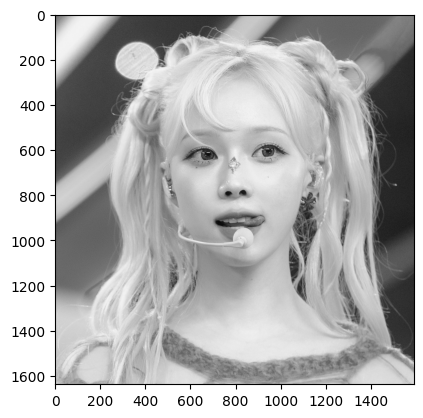

In [ ]:
img = cv2.imread('/content/gdrive/My Drive/IP/Ch01/wt.jpg')

print(img.shape)
gImg1 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(gImg1.shape)
plt.imshow(gImg1, cmap='gray')

In [ ]:
def saturation(val):
  if val > 255:
    return 255
  elif val < 0:
    return 0
  else:
    return val

In [ ]:
gPoint = np.zeros((gImg1.shape[0], gImg1.shape[1]), dtype=np.ubyte)

역 변환 실습

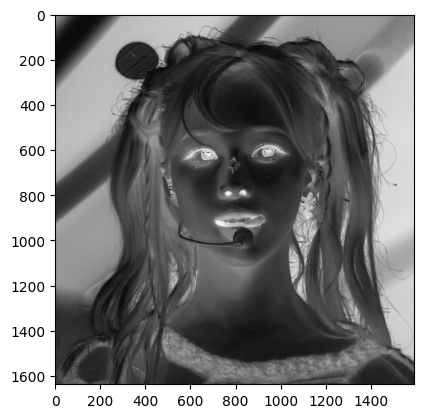

In [ ]:
for h in range(gImg1.shape[0]):
  for w in range(gImg1.shape[1]):
    PointVal = 255 - np.int32(gImg1[h, w])
    gPoint[h, w] = saturation(PointVal)

plt.imshow(gPoint, cmap='gray')

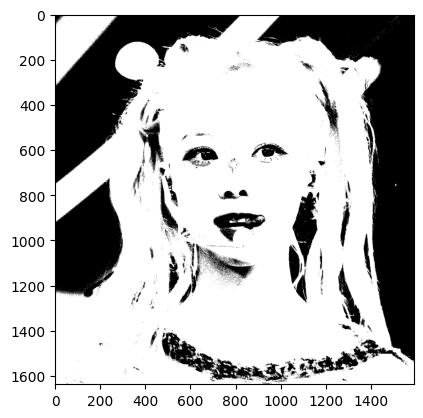

In [ ]:
th = 140

for h in range(gImg1.shape[0]):
  for w in range(gImg1.shape[1]):
    if gImg1[h, w] > th:
      gPoint[h, w] = 255
    else:
      gPoint[h, w] = 0

plt.imshow(gPoint, cmap='gray')

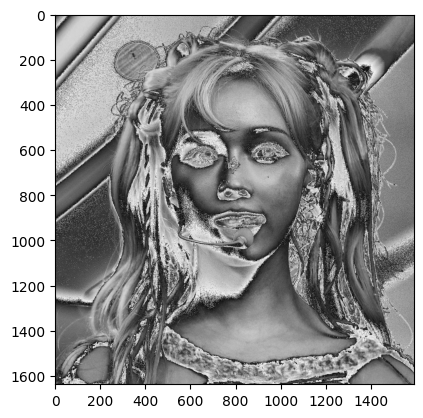

In [ ]:
numOfClip = 3
modVal = 256/numOfClip

for h in range(gImg1.shape[0]):
  for w in range(gImg1.shape[1]):
    pointVal = np.int32(gImg1[h, w]) % modVal
    gPoint[h, w] = saturation(pointVal * numOfClip)

plt.imshow(gPoint, cmap='gray', vmin=0, vmax=255)